# S7C-D1: strict-CV retarded-time EKF stress benchmark

This notebook audits the frozen paired experiment in `S7C_D1_PROTOCOL.md`. It evaluates the unchanged C1 model (`Q=0`) under event loss, station gaps, transport delay, and controlled non-Gaussian outliers. It does **not** add robust filtering or manoeuvre dynamics.

## Execution mode

The committed default is an explicitly labelled saved-result review. Set `RUN_FULL_STUDY=True` to regenerate all 200 independent base blocks (1800 paired profile-runs) before loading the CSV files. Reading saved CSV is not presented as a fresh Monte Carlo run.

In [1]:
from pathlib import Path
import csv
import json
import numpy as np
import matplotlib.pyplot as plt

from validation.retarded_ekf_stress_study import (
    DEFAULT_SEQUENCE_COUNT,
    run_retarded_ekf_stress_study,
)

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RESULTS = ROOT / 'results'
RUN_FULL_STUDY = False
if RUN_FULL_STUDY:
    run_retarded_ekf_stress_study(
        RESULTS, sequence_count=DEFAULT_SEQUENCE_COUNT, workers=8, progress=True
    )
MODE = 'fresh full Monte Carlo' if RUN_FULL_STUDY else 'saved-result review (no Monte Carlo rerun)'
print(MODE)

saved-result review (no Monte Carlo rerun)


## Data and independence contract

There are 100 independent whole sequences per geometry. Profiles sharing a geometry/sequence index reuse truth and nominal bearing noise deliberately, so 1800 profile-runs are dependent paired observations. Epochs inside a sequence are also dependent. Wilson intervals and bootstrap resampling therefore use whole sequences/base blocks, never epochs.

In [2]:
def read_rows(name):
    with (RESULTS / name).open(encoding='utf-8', newline='') as handle:
        return list(csv.DictReader(handle))

epoch = read_rows('retarded_ekf_stress_epoch_summary.csv')
sequence = read_rows('retarded_ekf_stress_sequence_results.csv')
profile = read_rows('retarded_ekf_stress_profile_summary.csv')
seeds = read_rows('retarded_ekf_stress_seed_provenance.csv')

expected = {'epoch': 1476, 'sequence': 7200, 'profile': 126, 'seeds': 200}
observed = {'epoch': len(epoch), 'sequence': len(sequence), 'profile': len(profile), 'seeds': len(seeds)}
assert observed == expected, (observed, expected)
assert len({row['geometry'] for row in seeds}) == 2
assert len({row['sequence_index'] for row in seeds}) == 100
seed_columns = [column for column in seeds[0] if column.endswith('_seed') and column != 'base_seed']
assert len({row[column] for row in seeds for column in seed_columns}) == 1200
print(observed)
print('Independent base blocks:', len(seeds), '; paired profile-runs:', 2 * 9 * 100)

{'epoch': 1476, 'sequence': 7200, 'profile': 126, 'seeds': 200}


Independent base blocks: 200 ; paired profile-runs: 1800


## Endpoint errors, validity, and coverage

Error metrics below are conditional on valid estimates; validity and `valid AND covered` retain all-sequence denominators. Outlier profiles intentionally violate the Gaussian observation model, so chi-square diagnostics are descriptive rather than calibration claims.

In [3]:
endpoint = [row for row in profile if float(row['evaluation_time_s']) == 14.5 and row['method'] != 'offline_full_batch']
display_columns = [
    'geometry', 'profile', 'method', 'valid_fraction',
    'conditional_position_rmse_m', 'conditional_position_p95_m',
    'conditional_velocity_rmse_mps', 'conditional_state_95_coverage_fraction',
    'unconditional_valid_and_covered_fraction',
]
for row in sorted(endpoint, key=lambda item: (item['geometry'], item['profile'], item['method'])):
    print(' | '.join(f'{column}={row[column]}' for column in display_columns))

geometry=informative | profile=all_station_gap | method=causal_prefix_batch | valid_fraction=1.0 | conditional_position_rmse_m=0.8082232293369701 | conditional_position_p95_m=1.421061851525715 | conditional_velocity_rmse_mps=0.07559187327658111 | conditional_state_95_coverage_fraction=0.9 | unconditional_valid_and_covered_fraction=0.9
geometry=informative | profile=all_station_gap | method=initial_batch_no_updates | valid_fraction=1.0 | conditional_position_rmse_m=16.21449742661201 | conditional_position_p95_m=27.35205512827701 | conditional_velocity_rmse_mps=1.1903986206979118 | conditional_state_95_coverage_fraction=0.97 | unconditional_valid_and_covered_fraction=0.97
geometry=informative | profile=all_station_gap | method=offline_full_record_noncausal | valid_fraction=1.0 | conditional_position_rmse_m=0.8082232293369701 | conditional_position_p95_m=1.421061851525715 | conditional_velocity_rmse_mps=0.07559187327658111 | conditional_state_95_coverage_fraction=0.9 | unconditional_valid

In [4]:
count_rows = [row for row in epoch if float(row['evaluation_time_s']) == 14.5 and row['method'] == 'retarded_ekf']
count_columns = [
    'geometry', 'profile', 'mean_potential_event_count',
    'mean_profile_delivered_event_count', 'mean_profile_lost_event_count',
    'mean_causally_available_event_count', 'mean_method_initialization_event_count',
    'mean_method_update_event_count', 'mean_method_rejected_event_count',
    'mean_stream_quarantined_event_count',
    'mean_method_remaining_unprocessed_available_count',
]
for row in sorted(count_rows, key=lambda item: (item['geometry'], item['profile'])):
    print(' | '.join(f'{column}={row[column]}' for column in count_columns))

geometry=informative | profile=all_station_gap | mean_potential_event_count=45.0 | mean_profile_delivered_event_count=29.0 | mean_profile_lost_event_count=16.0 | mean_causally_available_event_count=29.0 | mean_method_initialization_event_count=6.0 | mean_method_update_event_count=23.0 | mean_method_rejected_event_count=0.0 | mean_stream_quarantined_event_count=0.0 | mean_method_remaining_unprocessed_available_count=0.0
geometry=informative | profile=dropout_20 | mean_potential_event_count=45.0 | mean_profile_delivered_event_count=35.89 | mean_profile_lost_event_count=9.11 | mean_causally_available_event_count=35.89 | mean_method_initialization_event_count=6.0 | mean_method_update_event_count=29.89 | mean_method_rejected_event_count=0.0 | mean_stream_quarantined_event_count=0.0 | mean_method_remaining_unprocessed_available_count=0.0
geometry=informative | profile=dropout_50 | mean_potential_event_count=45.0 | mean_profile_delivered_event_count=22.34 | mean_profile_lost_event_count=22.66

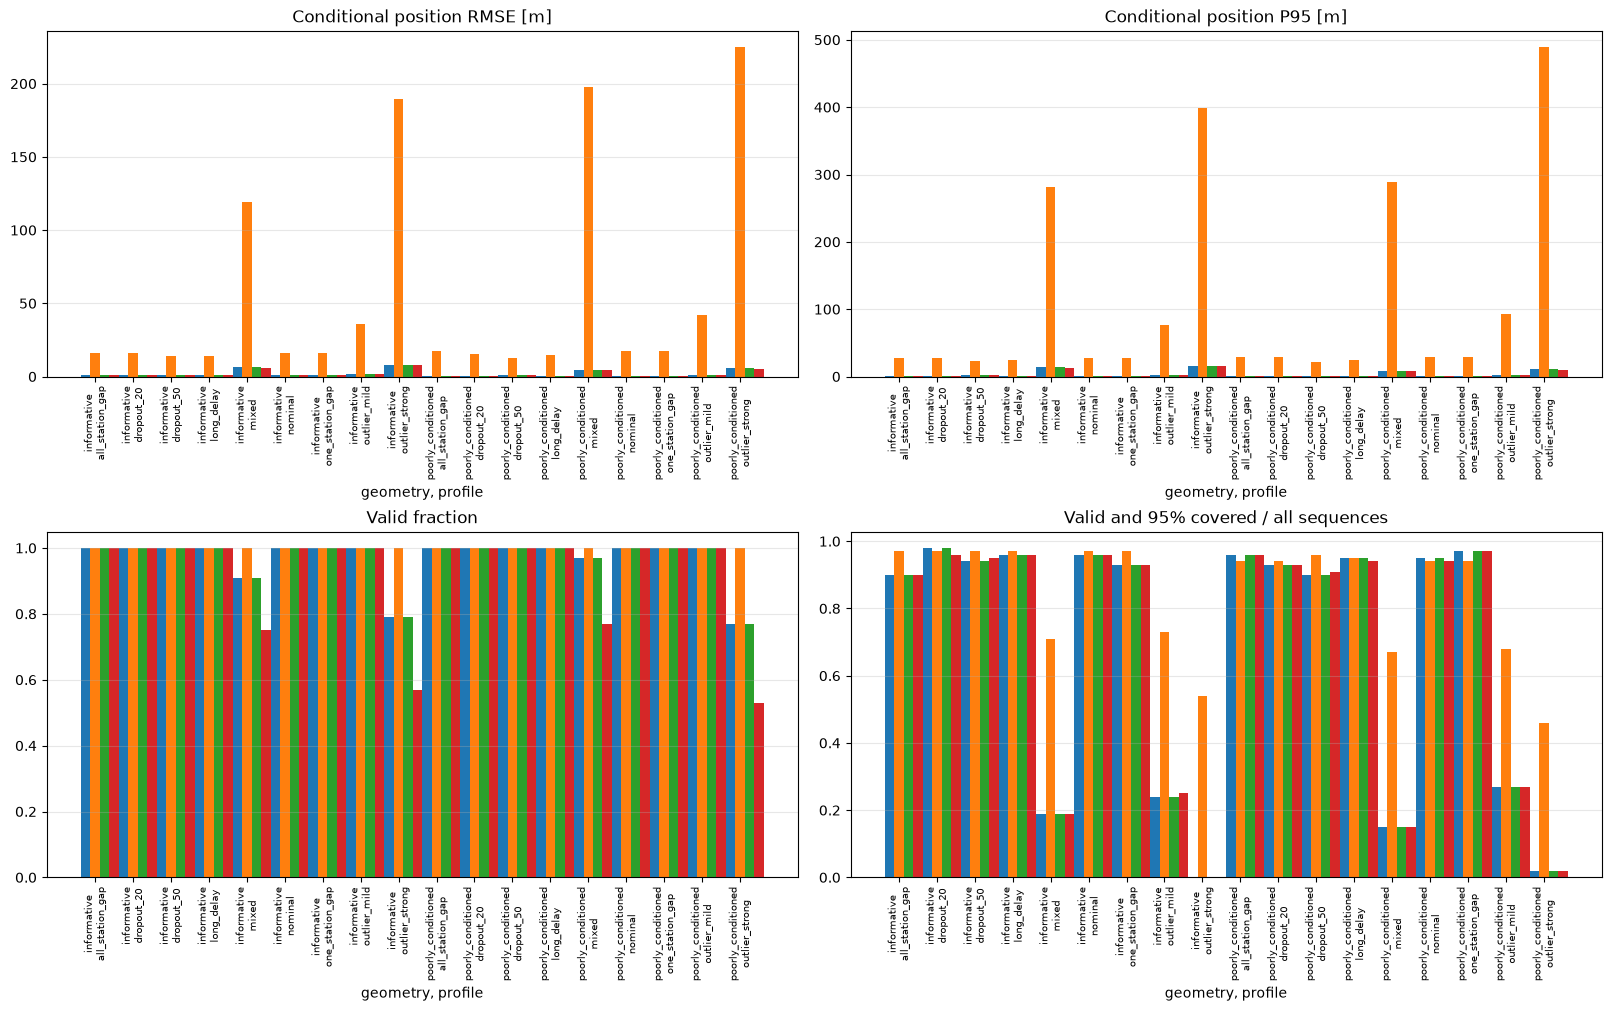

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
for column, title, axis in [
    ('conditional_position_rmse_m', 'Conditional position RMSE [m]', axes[0, 0]),
    ('conditional_position_p95_m', 'Conditional position P95 [m]', axes[0, 1]),
    ('valid_fraction', 'Valid fraction', axes[1, 0]),
    ('unconditional_valid_and_covered_fraction', 'Valid and 95% covered / all sequences', axes[1, 1]),
]:
    labels = sorted({f"{row['geometry']}\n{row['profile']}" for row in endpoint})
    methods = sorted({row['method'] for row in endpoint})
    width = 0.25
    x = np.arange(len(labels))
    lookup = {(f"{row['geometry']}\n{row['profile']}", row['method']): float(row[column]) for row in endpoint}
    for method_index, method in enumerate(methods):
        values = [lookup.get((label, method), np.nan) for label in labels]
        axis.bar(x + (method_index - 1) * width, values, width, label=method)
    axis.set_xticks(x, labels, rotation=90, fontsize=7)
    axis.set_title(title)
    axis.set_xlabel('geometry, profile')
    axis.grid(axis='y', alpha=0.3)
plt.show()

## Time evolution through station gaps

The curves use dependent epochs only to show dynamics. They are not independent-trial confidence intervals and post-gap values are not called recovery without a predeclared accuracy criterion.

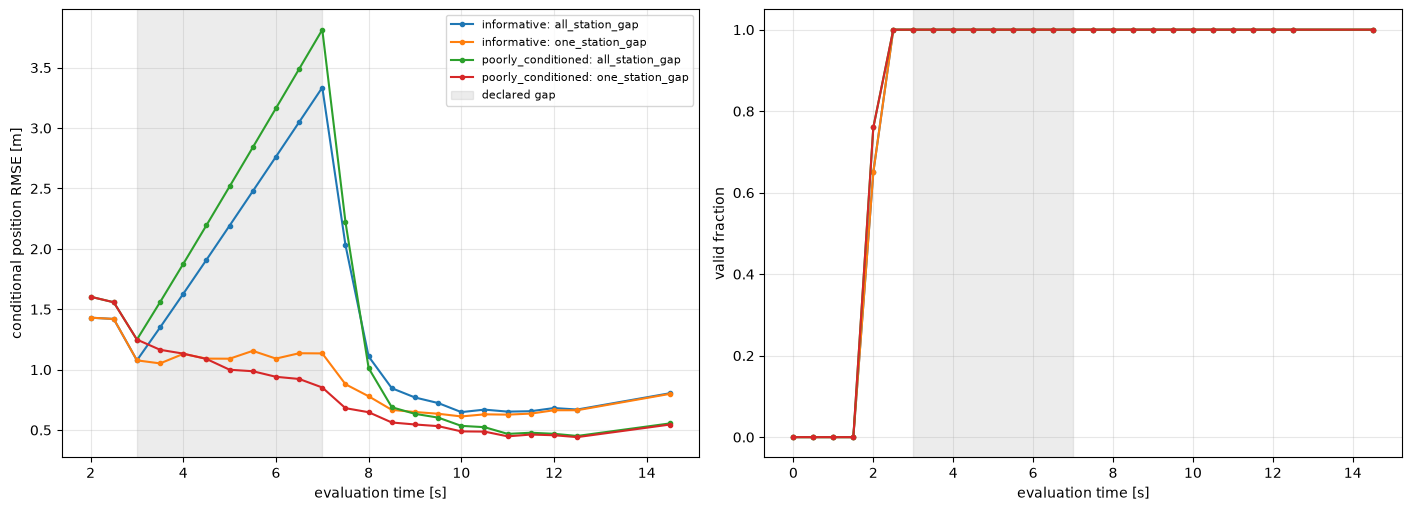

In [6]:
gap = [row for row in epoch if row['profile'] in {'one_station_gap', 'all_station_gap'} and row['method'] == 'retarded_ekf']
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for geometry, profile_name in sorted({(row['geometry'], row['profile']) for row in gap}):
    group = sorted((row for row in gap if row['geometry'] == geometry and row['profile'] == profile_name), key=lambda row: float(row['evaluation_time_s']))
    label = f'{geometry}: {profile_name}'
    axes[0].plot([float(row['evaluation_time_s']) for row in group], [float(row['conditional_position_rmse_m']) for row in group], marker='.', label=label)
    axes[1].plot([float(row['evaluation_time_s']) for row in group], [float(row['valid_fraction']) for row in group], marker='.', label=label)
for axis in axes:
    axis.axvspan(3.0, 7.0, color='grey', alpha=0.15, label='declared gap')
    axis.set_xlabel('evaluation time [s]')
    axis.grid(alpha=0.3)
axes[0].set_ylabel('conditional position RMSE [m]')
axes[1].set_ylabel('valid fraction')
axes[0].legend(fontsize=8)
plt.show()

## NIS and NEES diagnostics

NIS has two degrees of freedom per defined bearing innovation and NEES has six state degrees of freedom. Their Gaussian benchmarks apply only under the nominal model; dropout changes timing/information, while injected outliers also invalidate the nominal Gaussian error law.

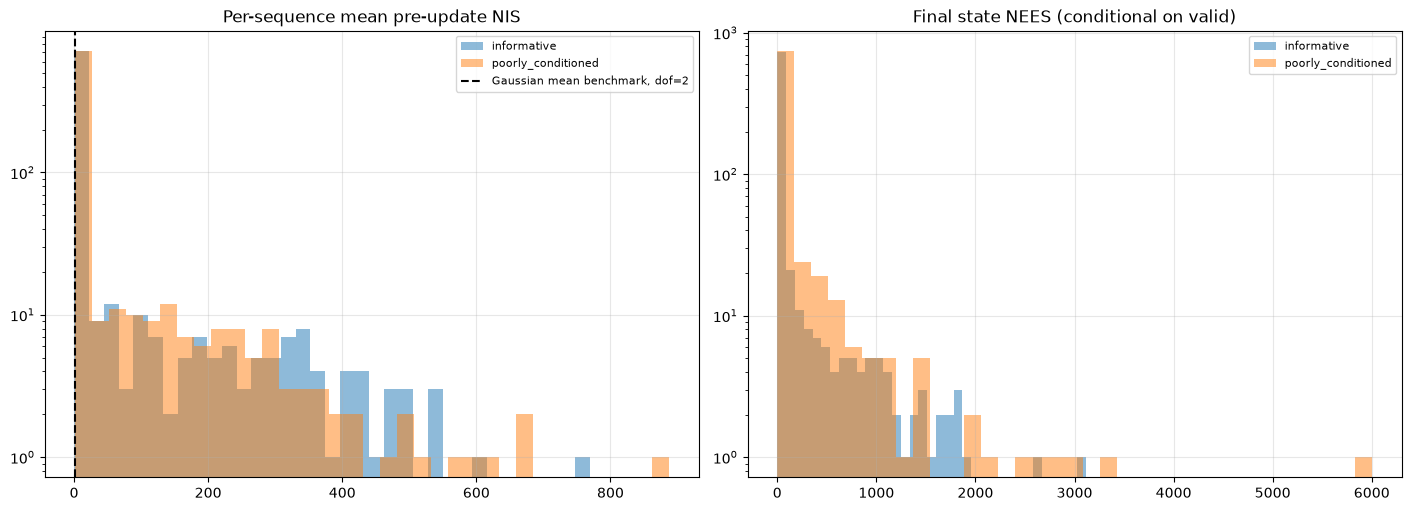

In [7]:
ekf_rows = [row for row in sequence if row['method'] == 'retarded_ekf']
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for geometry in sorted({row['geometry'] for row in ekf_rows}):
    group = [row for row in ekf_rows if row['geometry'] == geometry]
    finite_nis = np.asarray([float(row['mean_pre_update_nis']) for row in group])
    finite_nis = finite_nis[np.isfinite(finite_nis)]
    axes[0].hist(finite_nis, bins=35, alpha=0.5, label=geometry)
    finite_nees = np.asarray([float(row['at_14_5_s_state_nees']) for row in group])
    finite_nees = finite_nees[np.isfinite(finite_nees)]
    axes[1].hist(finite_nees, bins=35, alpha=0.5, label=geometry)
axes[0].axvline(2.0, color='black', linestyle='--', label='Gaussian mean benchmark, dof=2')
axes[0].set_title('Per-sequence mean pre-update NIS')
axes[1].set_title('Final state NEES (conditional on valid)')
for axis in axes:
    axis.set_yscale('log')
    axis.legend(fontsize=8)
    axis.grid(alpha=0.3)
plt.show()

## Predeclared illustrative sequence

Sequence index 0 is fixed by protocol before inspecting outcomes; it is not selected for visual appearance. The plot shows error rays only through scalar state errors and never changes estimator input.

In [8]:
illustrative = [row for row in sequence if int(row['sequence_index']) == 0 and row['method'] == 'retarded_ekf']
view_columns = [
    'geometry', 'profile', 'at_12_5_s_valid', 'at_12_5_s_position_error_m',
    'at_14_5_s_valid', 'at_14_5_s_position_error_m', 'delivered_event_count',
]
for row in sorted(illustrative, key=lambda item: (item['geometry'], item['profile'])):
    print(' | '.join(f'{column}={row[column]}' for column in view_columns))

geometry=informative | profile=all_station_gap | at_12_5_s_valid=True | at_12_5_s_position_error_m=0.948207407154502 | at_14_5_s_valid=True | at_14_5_s_position_error_m=1.184569032343724 | delivered_event_count=29
geometry=informative | profile=dropout_20 | at_12_5_s_valid=True | at_12_5_s_position_error_m=1.0884436894504237 | at_14_5_s_valid=True | at_14_5_s_position_error_m=1.3177364758422723 | delivered_event_count=35
geometry=informative | profile=dropout_50 | at_12_5_s_valid=True | at_12_5_s_position_error_m=1.4007157050885044 | at_14_5_s_valid=True | at_14_5_s_position_error_m=1.6891731233861864 | delivered_event_count=25
geometry=informative | profile=long_delay | at_12_5_s_valid=True | at_12_5_s_position_error_m=0.780123719705529 | at_14_5_s_valid=True | at_14_5_s_position_error_m=0.950867052774599 | delivered_event_count=45
geometry=informative | profile=mixed | at_12_5_s_valid=True | at_12_5_s_position_error_m=0.9414348987302109 | at_14_5_s_valid=True | at_14_5_s_position_err

## Interpretation limits

This benchmark measures failure modes of one strict constant-velocity, zero-process-noise baseline. At 14.5 s, nominal EKF validity is 1.0 in both geometries with position RMSE 0.756/0.536 m and unconditional 95% coverage 0.96/0.94. Mild 5-degree outliers retain validity 1.0 but reduce unconditional coverage to 0.25/0.27. Strong 20-degree outliers reduce validity to 0.57/0.53, coverage to 0.00/0.02, and increase conditional position RMSE to 7.79/5.09 m; the mixed profile gives validity 0.75/0.77 and RMSE 5.87/4.23 m. Conditional error must always be read together with valid fraction and the all-sequence `valid AND covered` fraction. The offline full batch is noncausal. Performance under injected outliers cannot be interpreted as a calibrated Gaussian NIS/NEES result, and no claim is made about manoeuvres, real acoustic frontends, wind, reflections, or real-time readiness.